**Question:** Write your **own function** to equalize the histogram of an image.
Apply this function to the **runway image**.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Load runway image (grayscale) — required by the assignment
runway = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert runway is not None, "Could not load runway.png"

# Also load shells for supplementary comparison
shells = cv.imread('../images/a1images/shells.tif', cv.IMREAD_GRAYSCALE)
assert shells is not None, "Could not load shells.tif"

print("runway.png:")
print(f"  Shape: {runway.shape} | Mean: {runway.mean():.2f} | Std: {runway.std():.2f}")
print(f"  Min: {runway.min()} | Max: {runway.max()}")
print()
print("shells.tif:")
print(f"  Shape: {shells.shape} | Mean: {shells.mean():.2f} | Std: {shells.std():.2f}")
print(f"  Min: {shells.min()} | Max: {shells.max()}")


runway.png:
  Shape: (769, 765) | Mean: 197.12 | Std: 40.88
  Min: 0 | Max: 255

shells.tif:
  Shape: (500, 500) | Mean: 38.75 | Std: 17.26
  Min: 13 | Max: 83


## Custom Histogram Equalization Function

In [2]:
def histogram_equalize(image):
    assert image.ndim == 2, "Input must be a grayscale (2D) image"
    assert image.dtype == np.uint8, "Input must be uint8"

    M, N = image.shape          # image dimensions
    L    = 256                  # number of intensity levels

    # ── Step 1: Compute histogram ──────────────────────────────────────────
    hist_in = np.zeros(L, dtype=np.int64)
    for pixel_val in image.ravel():
        hist_in[pixel_val] += 1
    # Equivalent one-liner (shown for clarity):
    # hist_in = np.histogram(image.ravel(), bins=256, range=(0, 256))[0]

    # ── Step 2: Compute CDF ────────────────────────────────────────────────
    cdf = np.cumsum(hist_in)

    # ── Step 3: Build lookup table (transfer function) ─────────────────────
    # t[k] = (L-1) / (M*N) * CDF[k], rounded to nearest integer
    lut = np.round((L - 1) / (M * N) * cdf).astype(np.uint8)

    # ── Step 4: Apply lookup table to every pixel ──────────────────────────
    equalized = lut[image]      # NumPy fancy indexing — maps each pixel

    # ── Compute output histogram for analysis ─────────────────────────────
    hist_out = np.zeros(L, dtype=np.int64)
    for pixel_val in equalized.ravel():
        hist_out[pixel_val] += 1

    return equalized, hist_in, hist_out, cdf, lut


print("histogram_equalize() function defined successfully.")


histogram_equalize() function defined successfully.


In [3]:
# ── Apply custom HE to the runway image ──────────────────────────────────────
runway_eq, hist_in, hist_out, cdf, lut = histogram_equalize(runway)

print("Runway — Before equalization:")
print(f"  Mean: {runway.mean():.2f} | Std: {runway.std():.2f} | Min: {runway.min()} | Max: {runway.max()}")
print()
print("Runway — After equalization:")
print(f"  Mean: {runway_eq.mean():.2f} | Std: {runway_eq.std():.2f} | Min: {runway_eq.min()} | Max: {runway_eq.max()}")


Runway — Before equalization:
  Mean: 197.12 | Std: 40.88 | Min: 0 | Max: 255

Runway — After equalization:
  Mean: 128.83 | Std: 73.93 | Min: 0 | Max: 255


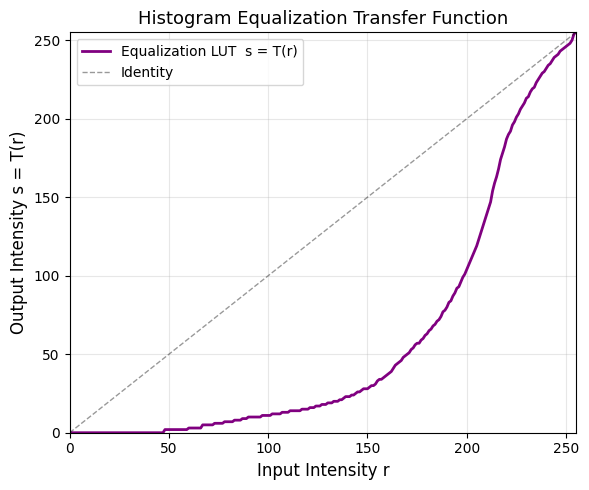

In [4]:
# ── Plot the equalization transfer function (lookup table) ───────────────────
os.makedirs('../outputs/q3', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(range(256), lut, color='purple', linewidth=2, label='Equalization LUT  s = T(r)')
ax.plot([0, 255], [0, 255], 'k--', alpha=0.4, linewidth=1, label='Identity')
ax.set_xlabel('Input Intensity r', fontsize=12)
ax.set_ylabel('Output Intensity s = T(r)', fontsize=12)
ax.set_title('Histogram Equalization Transfer Function', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 255])
ax.set_ylim([0, 255])
plt.tight_layout()
plt.savefig('../outputs/q3/q3_transfer_function.png', dpi=150, bbox_inches='tight')
plt.show()


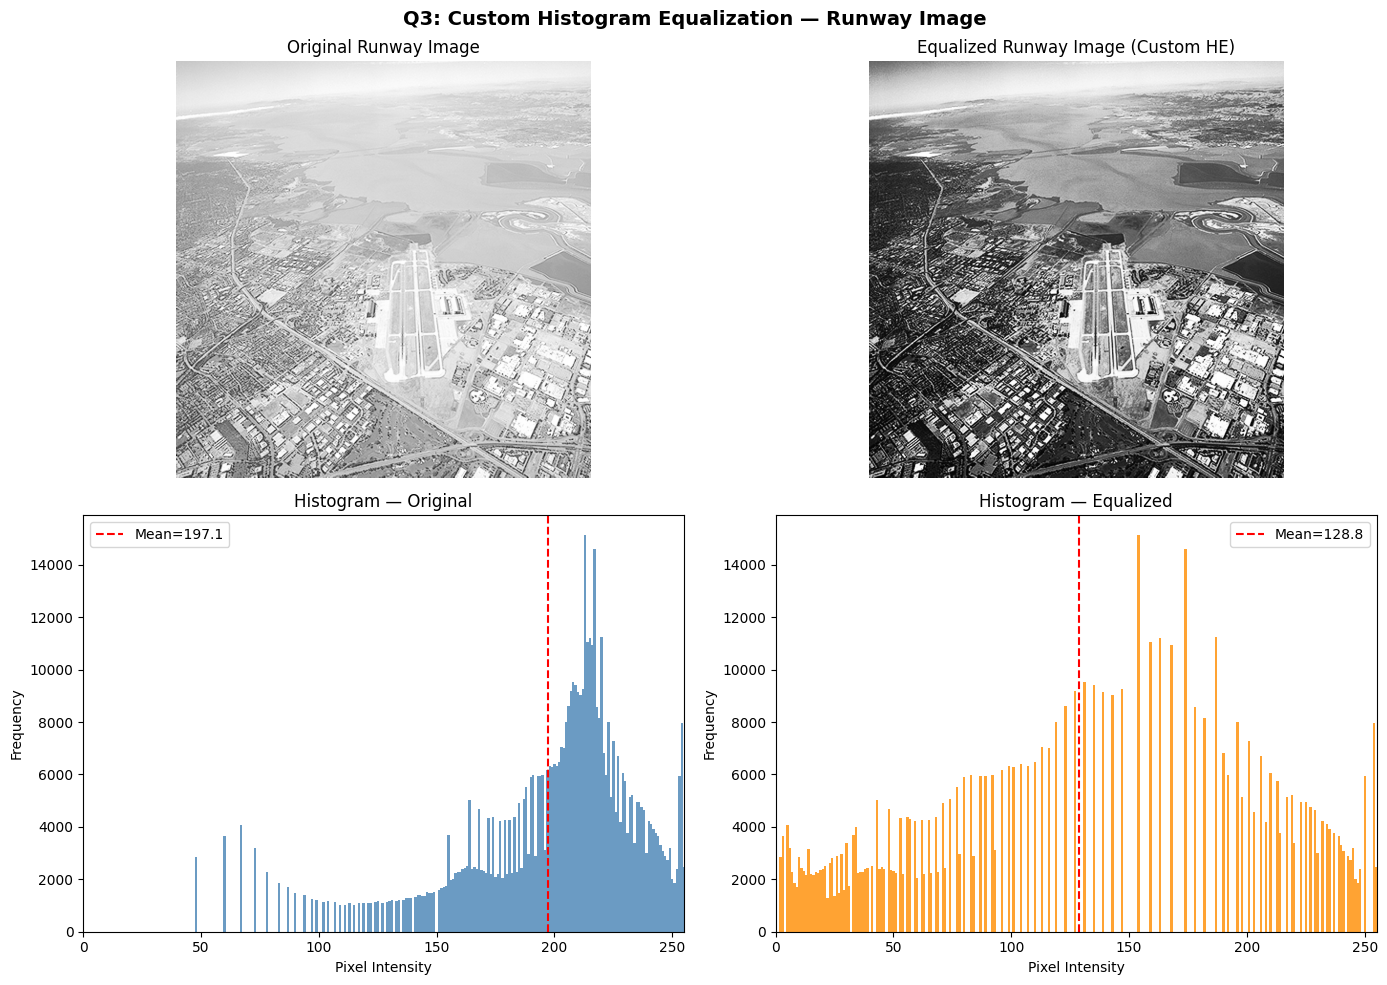

In [5]:
# ── Main result: runway original vs equalized ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q3: Custom Histogram Equalization — Runway Image', fontsize=14, fontweight='bold')

# Images
axes[0, 0].imshow(runway,    cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Runway Image', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(runway_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized Runway Image (Custom HE)', fontsize=12)
axes[0, 1].axis('off')

# Histograms
axes[1, 0].bar(range(256), hist_in,  color='steelblue', alpha=0.8, width=1.0)
axes[1, 0].set_title('Histogram — Original', fontsize=12)
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].axvline(runway.mean(), color='red', linestyle='--',
                   linewidth=1.5, label=f'Mean={runway.mean():.1f}')
axes[1, 0].legend()

axes[1, 1].bar(range(256), hist_out, color='darkorange', alpha=0.8, width=1.0)
axes[1, 1].set_title('Histogram — Equalized', fontsize=12)
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].axvline(runway_eq.mean(), color='red', linestyle='--',
                   linewidth=1.5, label=f'Mean={runway_eq.mean():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../outputs/q3/q3_runway_results.png', dpi=150, bbox_inches='tight')
plt.show()


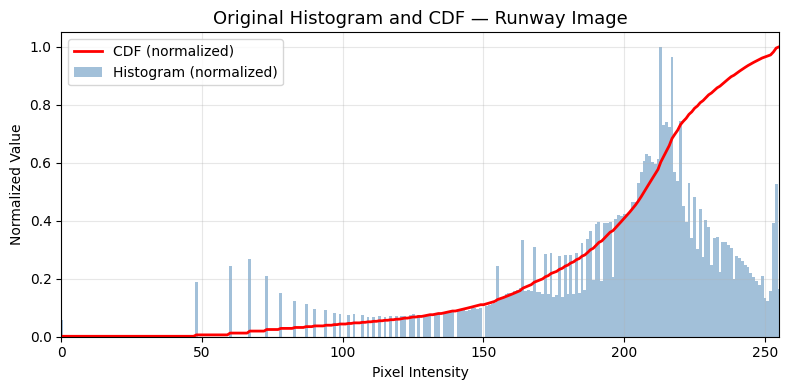

In [6]:
# ── Plot the CDF ─────────────────────────────────────────────────────────────
cdf_normalized = cdf / cdf.max()   # normalize to [0, 1] for overlay

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(256), hist_in / hist_in.max(), color='steelblue', alpha=0.5,
       width=1.0, label='Histogram (normalized)')
ax.plot(range(256), cdf_normalized, color='red', linewidth=2, label='CDF (normalized)')
ax.set_title('Original Histogram and CDF — Runway Image', fontsize=13)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Normalized Value')
ax.set_xlim([0, 255])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/q3/q3_cdf.png', dpi=150, bbox_inches='tight')
plt.show()


## Validation Against OpenCV

In [7]:
# ── Compare custom HE vs OpenCV equalizeHist ─────────────────────────────────
runway_cv_eq = cv.equalizeHist(runway)

# Compute pixel-wise difference
diff = cv.absdiff(runway_eq, runway_cv_eq)
max_diff  = diff.max()
mean_diff = diff.mean()

print(f"Max pixel difference  (custom vs OpenCV): {max_diff}")
print(f"Mean pixel difference (custom vs OpenCV): {mean_diff:.4f}")
print()
if max_diff <= 1:
    print("VALIDATION PASSED — results match OpenCV (difference ≤ 1 due to rounding)")
else:
    print("VALIDATION FAILED — check the implementation")


Max pixel difference  (custom vs OpenCV): 1
Mean pixel difference (custom vs OpenCV): 0.1693

VALIDATION PASSED — results match OpenCV (difference ≤ 1 due to rounding)


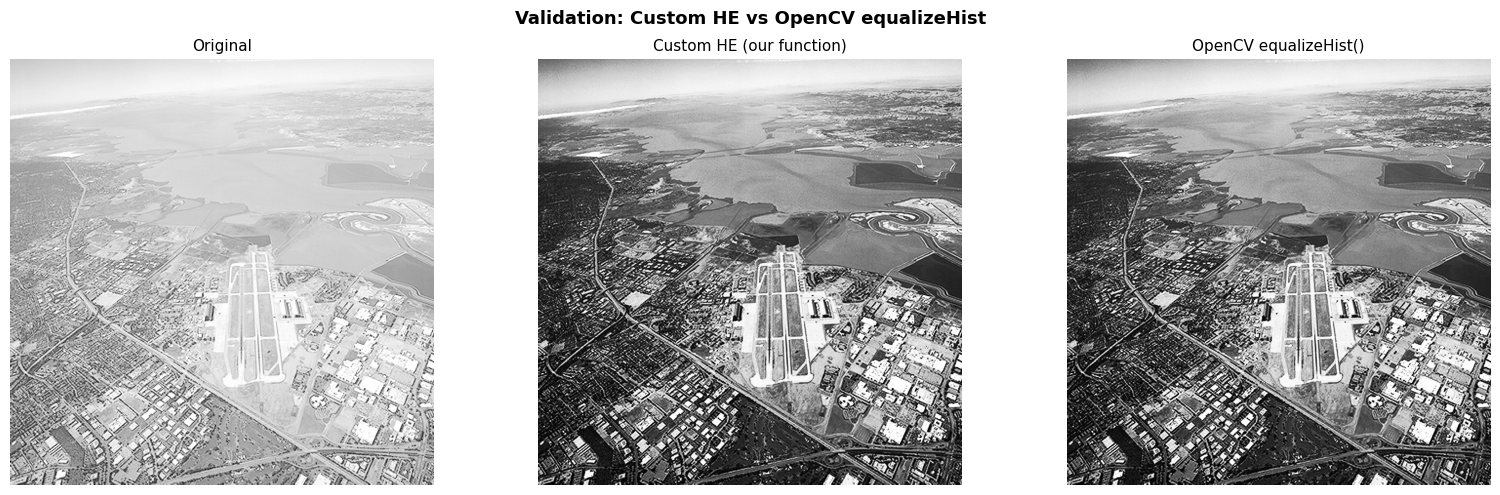

In [8]:
# ── Side-by-side: custom vs OpenCV ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Validation: Custom HE vs OpenCV equalizeHist', fontsize=13, fontweight='bold')

axes[0].imshow(runway,        cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original',            fontsize=11); axes[0].axis('off')

axes[1].imshow(runway_eq,     cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Custom HE (our function)', fontsize=11); axes[1].axis('off')

axes[2].imshow(runway_cv_eq,  cmap='gray', vmin=0, vmax=255)
axes[2].set_title('OpenCV equalizeHist()',   fontsize=11); axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## Supplementary: shells.tif

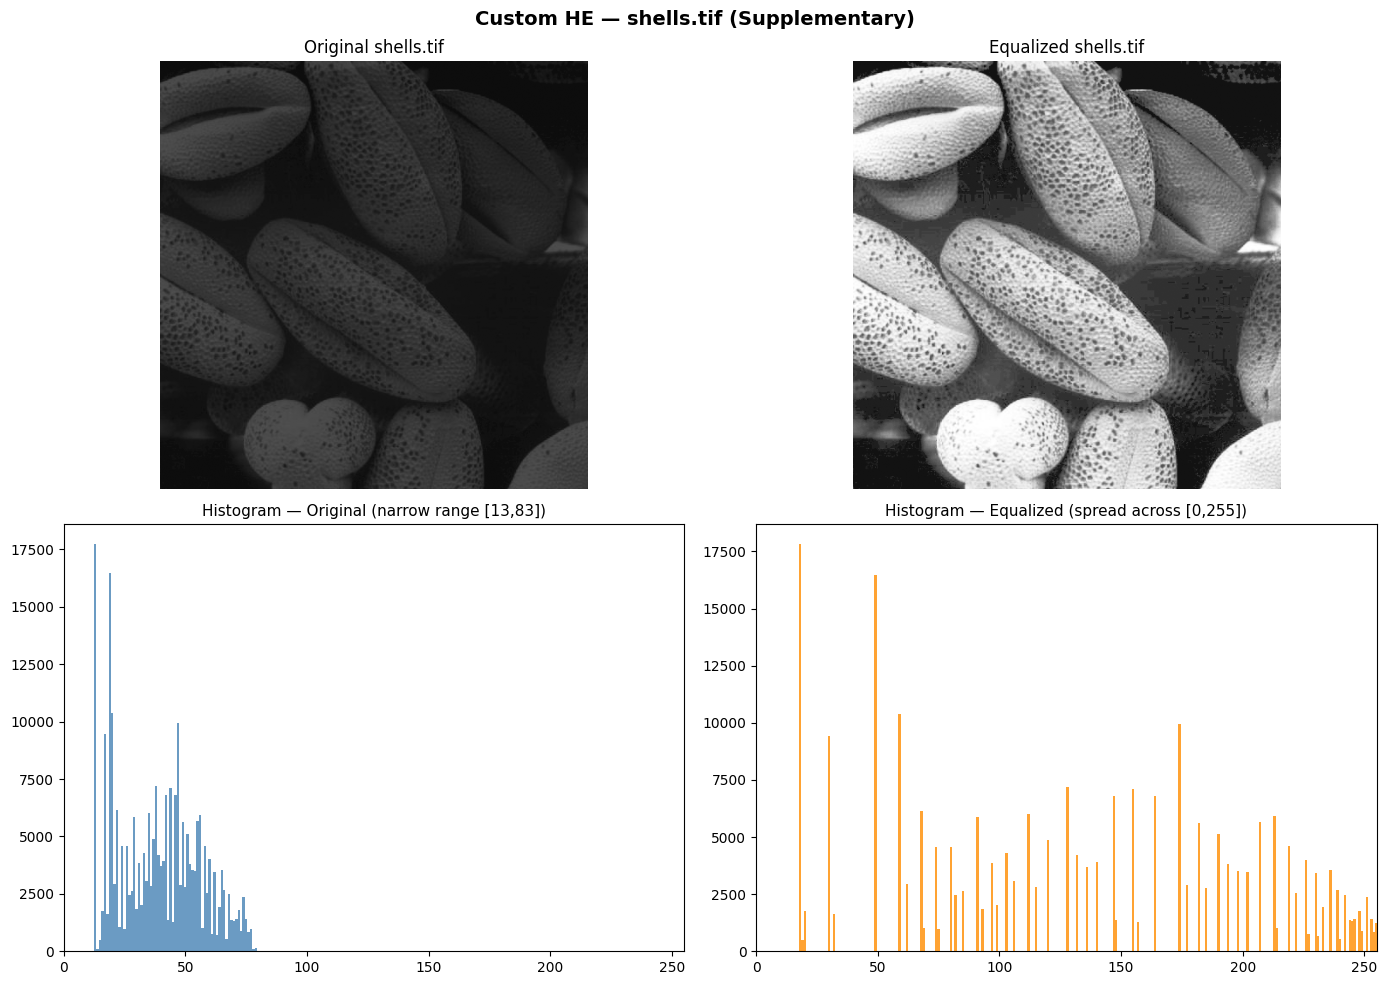

In [9]:
# ── Apply custom HE to shells.tif ────────────────────────────────────────────
shells_eq, shells_hist_in, shells_hist_out, _, _ = histogram_equalize(shells)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Custom HE — shells.tif (Supplementary)', fontsize=14, fontweight='bold')

axes[0, 0].imshow(shells,    cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original shells.tif', fontsize=12); axes[0, 0].axis('off')

axes[0, 1].imshow(shells_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized shells.tif', fontsize=12); axes[0, 1].axis('off')

axes[1, 0].bar(range(256), shells_hist_in,  color='steelblue',  alpha=0.8, width=1.0)
axes[1, 0].set_title('Histogram — Original (narrow range [13,83])', fontsize=11)
axes[1, 0].set_xlim([0, 255])

axes[1, 1].bar(range(256), shells_hist_out, color='darkorange', alpha=0.8, width=1.0)
axes[1, 1].set_title('Histogram — Equalized (spread across [0,255])', fontsize=11)
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.savefig('../outputs/q3/q3_shells_supplementary.png', dpi=150, bbox_inches='tight')
plt.show()
